In [ ]:
# Save preprocessed data to disk for reuse in notebooks 02, 03, 04
output_dir = Path("../data/processed")
output_path = output_dir / "preprocessed_cranfield.pkl"

save_preprocessed(preprocessed_data, output_path)
print(f"Preprocessed data saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / (1024**2):.2f} MB")

In [ ]:
# Example: inspect preprocessed output for the first document and first query
print("\nExample preprocessing for the first document:")
print(f"Original (raw): {df_docs.iloc[0]['title']} | {df_docs.iloc[0]['text'][:100]}...")
print(f"\nTokenized outputs:")
for config_name in PREPROCESSING_CONFIGS.keys():
    tokens = preprocessed_data[config_name]["docs"][0]
    print(f"  {config_name}: {tokens[:10]}... ({len(tokens)} tokens total)")

print("\n" + "="*80)
print("Example preprocessing for the first query:")
print(f"Original (raw): {df_queries.iloc[0]['text']}")
print(f"\nTokenized outputs:")
for config_name in PREPROCESSING_CONFIGS.keys():
    tokens = preprocessed_data[config_name]["queries"][0]
    print(f"  {config_name}: {tokens}")

In [ ]:
# Generate vocabulary statistics for each configuration
stats_list = []
for config_name, config_data in preprocessed_data.items():
    stats = vocabulary_stats(config_data["docs"])
    stats["Configuration"] = config_name
    stats_list.append(stats)

df_vocab_stats = pd.DataFrame(stats_list)
df_vocab_stats = df_vocab_stats[["Configuration", "vocabulary_size", "total_tokens", "avg_tokens_per_doc"]]
df_vocab_stats.columns = ["Configuration", "Vocabulary Size", "Total Tokens", "Avg Tokens/Doc"]

print("\nVocabulary Statistics by Configuration:")
display(df_vocab_stats)

In [ ]:
# Build preprocessed data for all 4 configurations
print("Building preprocessed data for all 4 configurations...")
preprocessed_data = build_all_configs(df_docs, df_queries)
print("Done!")

In [ ]:
import pandas as pd
import ir_datasets
from collections import Counter
import matplotlib.pyplot as plt

# Load the Cranfield dataset using ir_datasets
dataset = ir_datasets.load("cranfield")

# Convert the dataset to pandas DataFrames for easier analysis
df_docs = pd.DataFrame(dataset.docs_iter())
df_queries = pd.DataFrame(dataset.queries_iter())
df_qrels = pd.DataFrame(dataset.qrels_iter())

In [4]:
# Analyze the structure of the DataFrames
display(df_queries.head())

# Analyze the word length of the queries to support the critical analysis in the report
df_queries['words_length'] = df_queries['text'].apply(lambda x: len(x.split()))
display(df_queries['words_length'].describe())


,query_id,text
0,1,what similarity laws must be obeyed when const...
1,2,what are the structural and aeroelastic proble...
2,3,what problems of heat conduction in composite ...
3,4,can a criterion be developed to show empirical...
4,5,what chemical kinetic system is applicable to ...


count    225.000000
mean      17.973333
std        7.131995
min        6.000000
25%       13.000000
50%       17.000000
75%       22.000000
max       46.000000
Name: words_length, dtype: float64

In [5]:
# Analyze the distribution of relevance scores in the qrels DataFrame
display(df_qrels['relevance'].value_counts())

# Create a new column 'is_relevant' in the qrels DataFrame to indicate whether a document is relevant (1) or not (0) based on the relevance score
df_qrels['is_relevant'] = df_qrels['relevance'].apply(lambda x: 1 if x >= 1 else 0)

# Analyze the number of relevant documents per query
relevantes_por_query = df_qrels[df_qrels['is_relevant'] == 1].groupby('query_id').size()
print("\nRelevant documents per query:")
display(relevantes_por_query.describe())

relevance
 3    734
 2    387
 4    363
-1    225
 1    128
Name: count, dtype: int64


Relevant documents per query:


count    225.000000
mean       7.164444
std        5.388031
min        1.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       39.000000
dtype: float64

In [6]:
# Analyze the structure of the documents DataFrame
display(df_docs.isna().sum())

# Analyze the length of the documents to support the critical analysis in the report
df_docs['text_length'] = df_docs['text'].apply(lambda x: len(str(x).split()))
print("\nStatistics of document lengths:")
display(df_docs['text_length'].describe())

doc_id    0
title     0
text      0
author    0
bib       0
dtype: int64


Statistics of document lengths:


count    1400.000000
mean      164.080000
std        88.695965
min         0.000000
25%        99.000000
50%       144.000000
75%       214.000000
max       669.000000
Name: text_length, dtype: float64

In [ ]:
# Union of all words in the documents, converted to lowercase and split into individual words
all_words = ' '.join(df_docs['text'].dropna()).lower().split()
words_count = Counter(all_words)

# Create a DataFrame to display the 20 most common words in the documents along with their frequencies
df_freq = pd.DataFrame(words_count.most_common(20), columns=['Termo', 'Frequência'])
display(df_freq)

,Termo,Frequência
0,the,19408
1,of,12597
2,.,9440
3,and,6085
4,a,5820
5,in,4579
6,to,4507
7,is,4068
8,for,3468
9,are,2415


In [9]:
# Analyze the number of relevant documents per query to identify queries with 2 or fewer relevant documents
qrels_relevants = df_qrels[df_qrels['is_relevant'] == 1]

# Count the number of relevant documents for each query
relevants_count = qrels_relevants.groupby('query_id').size()

# Identify queries with 2 or fewer relevant documents
dificult_queries = relevants_count[relevants_count <= 2]
print(f"Queries with 2 or fewer relevant documents: {len(dificult_queries)}")
display(dificult_queries.head())

Queries with 2 or fewer relevant documents: 35


query_id
103    2
112    2
117    2
119    1
123    2
dtype: int64

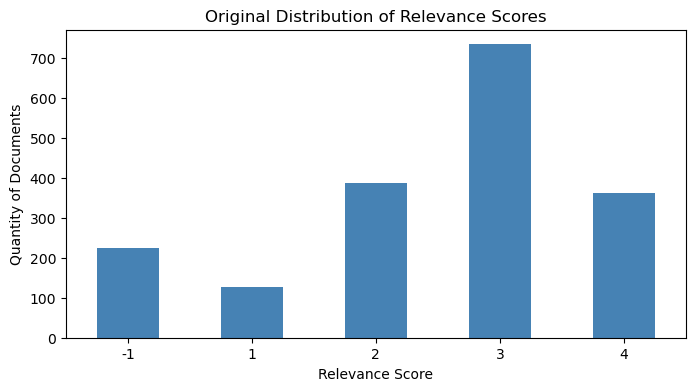

In [ ]:
# Plot the original distribution of relevance scores
df_qrels['relevance'].value_counts().sort_index().plot(
    kind='bar', 
    color='steelblue', 
    figsize=(8, 4),
    title='Original Distribution of Relevance Scores'
)
plt.xlabel('Relevance Score')
plt.ylabel('Quantity of Documents')
plt.xticks(rotation=0)
plt.show()

In [ ]:
import sys
sys.path.insert(0, '../')

from src.pre_processing import (
    ensure_nltk_resources,
    build_all_configs,
    vocabulary_stats,
    save_preprocessed,
    PREPROCESSING_CONFIGS,
)
from pathlib import Path

# Ensure NLTK resources are downloaded
ensure_nltk_resources()